#  Preprocessing FD002

**Différences vs FD001 :**
- 6 conditions opérationnelles (au lieu de 1) 3 op_setting qui forment 6 conditions diff
- 260 moteurs (au lieu de 100)
- Settings opérationnels varient → on les garde !

| Paramètre | Valeur |
|-----------|--------|
| Window size | 30 |
| RUL cap | 125 |
| Scaler | Global MinMax |
| Features | Mêmes 14 capteurs que FD001 |

## 1. Setup & Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json, os, joblib
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')
print(' Imports OK')

 Imports OK


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR   = '/content/drive/MyDrive/industrial-ai-platform'
DATA_DIR   = f'{BASE_DIR}/Data/cmapss'
OUTPUT_DIR = f'{BASE_DIR}/preprocessing_FD002'
CONFIG_PATH = f'{BASE_DIR}/feature_config.json'

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Chemins FD002
TRAIN_PATH = f'{DATA_DIR}/train_FD002.txt'
TEST_PATH  = f'{DATA_DIR}/test_FD002.txt'
RUL_PATH   = f'{DATA_DIR}/RUL_FD002.txt'

print(f'Chemins définis')
print(f'Output : {OUTPUT_DIR}')

Mounted at /content/drive
Chemins définis
Output : /content/drive/MyDrive/industrial-ai-platform/preprocessing_FD002


## 2. Chargement des données

In [ ]:
COLUMNS = [
    'unit_id', 'time_cycle',
    'op_setting_1', 'op_setting_2', 'op_setting_3',
    *[f'sensor_{i:02d}' for i in range(1, 22)]
]

df_train = pd.read_csv(TRAIN_PATH, sep=r'\s+', header=None, names=COLUMNS)
df_test  = pd.read_csv(TEST_PATH,  sep=r'\s+', header=None, names=COLUMNS)
df_rul   = pd.read_csv(RUL_PATH,   header=None, names=['RUL_true'])

print(f'Train : {df_train.shape} | {df_train["unit_id"].nunique()} moteurs')
print(f'Test  : {df_test.shape}  | {df_test["unit_id"].nunique()} moteurs')
print(f'RUL ground truth : {len(df_rul)} valeurs')

Train : (53759, 26) | 260 moteurs
Test  : (33991, 26)  | 259 moteurs
RUL ground truth : 259 valeurs


## 3. Charger le feature config de FD001

In [ ]:
# On réutilise exactement les mêmes capteurs sélectionnés pour FD001
with open(CONFIG_PATH) as f:
    config = json.load(f)

SENSORS_TO_KEEP = config['sensors_to_keep']
SENSORS_TO_DROP = config['sensors_to_drop']
RUL_CAP         = config['rul_cap']          # 125
WINDOW_SIZE     = 30
N_FEATURES      = len(SENSORS_TO_KEEP)        # 14

print(f'Capteurs retenus ({N_FEATURES}) : {SENSORS_TO_KEEP}')
print(f'RUL cap : {RUL_CAP}')
print(f'Window size : {WINDOW_SIZE}')

Capteurs retenus (14) : ['sensor_02', 'sensor_03', 'sensor_04', 'sensor_07', 'sensor_08', 'sensor_09', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']
RUL cap : 125
Window size : 30


## 4. EDA rapide FD002
**FD002 a 6 conditions opérationnelles — vérifions ça**

In [ ]:
# Distribution des settings opérationnels
print('=== Settings opérationnels FD002 ===')
print(df_train[['op_setting_1', 'op_setting_2', 'op_setting_3']].describe().round(3))

# Nombre de conditions uniques
print(f'\nValeurs uniques op_setting_1 : {df_train["op_setting_1"].nunique()}')
print(f'Valeurs uniques op_setting_2 : {df_train["op_setting_2"].nunique()}')
print(f'Valeurs uniques op_setting_3 : {df_train["op_setting_3"].nunique()}')

=== Settings opérationnels FD002 ===
       op_setting_1  op_setting_2  op_setting_3
count     53759.000     53759.000     53759.000
mean         23.998         0.572        94.046
std          14.747         0.310        14.238
min           0.000         0.000        60.000
25%          10.005         0.251       100.000
50%          25.001         0.700       100.000
75%          41.998         0.840       100.000
max          42.008         0.842       100.000

Valeurs uniques op_setting_1 : 536
Valeurs uniques op_setting_2 : 105
Valeurs uniques op_setting_3 : 2


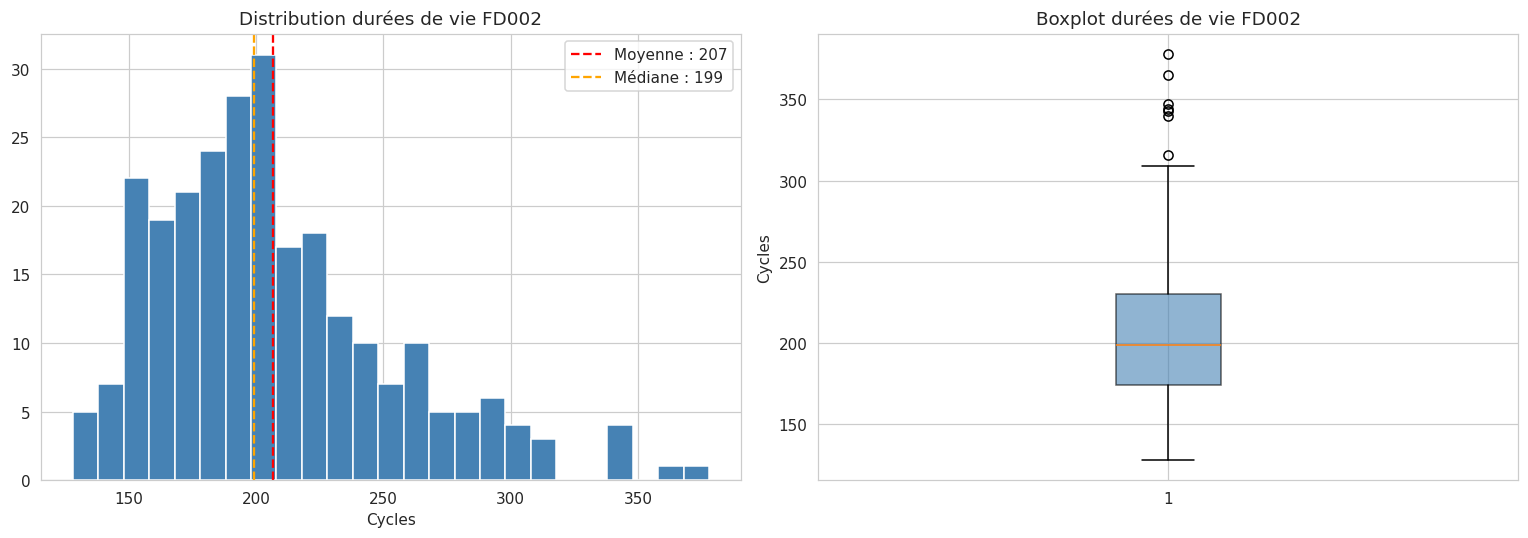


 Statistiques :
count    260.0
mean     206.8
std       46.8
min      128.0
25%      174.0
50%      199.0
75%      230.2
max      378.0
Name: time_cycle, dtype: float64


In [ ]:
# Distribution des durées de vie
lifetimes = df_train.groupby('unit_id')['time_cycle'].max()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(lifetimes, bins=25, color='steelblue', edgecolor='white')
axes[0].axvline(lifetimes.mean(),   color='red',    linestyle='--', label=f'Moyenne : {lifetimes.mean():.0f}')
axes[0].axvline(lifetimes.median(), color='orange', linestyle='--', label=f'Médiane : {lifetimes.median():.0f}')
axes[0].set_title('Distribution durées de vie FD002', fontsize=12)
axes[0].set_xlabel('Cycles')
axes[0].legend()

axes[1].boxplot(lifetimes, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Boxplot durées de vie FD002', fontsize=12)
axes[1].set_ylabel('Cycles')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fd002_lifetime_distribution.png', bbox_inches='tight')
plt.show()

print(f'\n Statistiques :')
print(lifetimes.describe().round(1))

## 5. Calcul du RUL + Clipping

In [ ]:
# Calcul RUL
max_cycles = df_train.groupby('unit_id')['time_cycle'].max().rename('max_cycle')
df_train   = df_train.merge(max_cycles, on='unit_id')
df_train['RUL'] = df_train['max_cycle'] - df_train['time_cycle']

# Clipping à 125
df_train['RUL'] = df_train['RUL'].clip(upper=RUL_CAP)

# RUL test depuis fichier ground truth
test_max = df_test.groupby('unit_id')['time_cycle'].max().reset_index()
test_max.columns = ['unit_id', 'max_cycle_test']
df_test  = df_test.merge(test_max, on='unit_id')
df_rul['unit_id'] = range(1, len(df_rul) + 1)
df_test  = df_test.merge(df_rul, on='unit_id')
df_test['RUL'] = df_test['RUL_true'] + (df_test['max_cycle_test'] - df_test['time_cycle'])
df_test['RUL'] = df_test['RUL'].clip(upper=RUL_CAP)

pct = (df_train['RUL'] == RUL_CAP).mean() * 100
print(f' RUL calculé et plafonné à {RUL_CAP}')
print(f'{pct:.1f}% des lignes plafonnées à {RUL_CAP}')

 RUL calculé et plafonné à 125
39.5% des lignes plafonnées à 125


## 6. Feature Selection + Drop colonnes

In [ ]:
SETTING_COLS = ['op_setting_1', 'op_setting_2', 'op_setting_3']

# Pour FD002 : les settings varient → on les GARDE contrairement à FD001
# On drop uniquement les capteurs inutiles
COLS_TO_DROP = SENSORS_TO_DROP + ['max_cycle', 'max_cycle_test', 'RUL_true']

df_train = df_train.drop(columns=[c for c in COLS_TO_DROP if c in df_train.columns])
df_test  = df_test.drop(columns=[c for c in COLS_TO_DROP if c in df_test.columns])

# Features = capteurs + settings (FD002 a plusieurs conditions)
FEATURE_COLS = SENSORS_TO_KEEP + SETTING_COLS
N_FEATURES   = len(FEATURE_COLS)

print(f'Feature cols ({N_FEATURES}) : {FEATURE_COLS}')
print(f'Shape train : {df_train.shape}')
print(f'Shape test  : {df_test.shape}')

Feature cols (17) : ['sensor_02', 'sensor_03', 'sensor_04', 'sensor_07', 'sensor_08', 'sensor_09', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21', 'op_setting_1', 'op_setting_2', 'op_setting_3']
Shape train : (53759, 20)
Shape test  : (33991, 20)


## 7. Normalisation — Scaler Global

In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))

# Fit sur train uniquement
df_train[FEATURE_COLS] = scaler.fit_transform(df_train[FEATURE_COLS])

# Transform sur test — même scaler
df_test[FEATURE_COLS]  = scaler.transform(df_test[FEATURE_COLS])

# Sauvegarder
joblib.dump(scaler, f'{OUTPUT_DIR}/minmax_scaler_FD002.pkl')

print(' Scaler global appliqué et sauvegardé')
print('\nPlage après normalisation (train) :')
print(df_train[FEATURE_COLS].agg(['min','max']).T.round(3).head(5))

 Scaler global appliqué et sauvegardé

Plage après normalisation (train) :
           min  max
sensor_02  0.0  1.0
sensor_03  0.0  1.0
sensor_04  0.0  1.0
sensor_07  0.0  1.0
sensor_08  0.0  1.0


## 8. Fenêtres Glissantes (Window Size = 30)

In [ ]:
def create_sequences(df, feature_cols, window_size=30):
    X_list, y_list = [], []
    for unit_id, group in df.groupby('unit_id'):
        data   = group[feature_cols].values
        labels = group['RUL'].values
        T = len(data)
        if T < window_size:
            pad    = np.repeat(data[[0]], window_size - T, axis=0)
            data   = np.vstack([pad, data])
            pad_y  = np.repeat(labels[0], window_size - T)
            labels = np.concatenate([pad_y, labels])
            T = window_size
        for t in range(T - window_size + 1):
            X_list.append(data[t : t + window_size])
            y_list.append(labels[t + window_size - 1])
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)


def create_test_sequences(df, feature_cols, window_size=30):
    X_list, y_list = [], []
    for unit_id, group in df.groupby('unit_id'):
        data   = group[feature_cols].values
        labels = group['RUL'].values
        T = len(data)
        if T < window_size:
            pad    = np.repeat(data[[0]], window_size - T, axis=0)
            data   = np.vstack([pad, data])
            labels = np.concatenate([np.repeat(labels[0], window_size - T), labels])
        X_list.append(data[-window_size:])
        y_list.append(labels[-1])
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)


print(f'Création des fenêtres (W={WINDOW_SIZE})...')
X_train_full, y_train_full = create_sequences(df_train, FEATURE_COLS, WINDOW_SIZE)
X_test,       y_test       = create_test_sequences(df_test, FEATURE_COLS, WINDOW_SIZE)

print(f' X_train_full : {X_train_full.shape}')
print(f' X_test       : {X_test.shape}')
print(f' y_train_full : {y_train_full.shape}')
print(f' y_test       : {y_test.shape}')

Création des fenêtres (W=30)...
 X_train_full : (46219, 30, 17)
 X_test       : (259, 30, 17)
 y_train_full : (46219,)
 y_test       : (259,)


## 9. Sauvegarder unit_ids + fichiers .npy

In [ ]:
# Construire et sauvegarder unit_ids
max_cycles_raw = df_train.groupby('unit_id')['time_cycle'].max()
unit_ids_per_seq = []
for uid, cnt in max_cycles_raw.items():
    n_seq = max(cnt - WINDOW_SIZE + 1, 1)
    unit_ids_per_seq.extend([uid] * n_seq)
unit_ids_per_seq = np.array(unit_ids_per_seq)

# Sauvegarder tout
np.save(f'{OUTPUT_DIR}/X_train.npy',        X_train_full)
np.save(f'{OUTPUT_DIR}/y_train.npy',        y_train_full)
np.save(f'{OUTPUT_DIR}/X_test.npy',         X_test)
np.save(f'{OUTPUT_DIR}/y_test.npy',         y_test)
np.save(f'{OUTPUT_DIR}/unit_ids_train.npy', unit_ids_per_seq)

print('Fichiers sauvegardés :')
for name in ['X_train', 'y_train', 'X_test', 'y_test', 'unit_ids_train']:
    path = f'{OUTPUT_DIR}/{name}.npy'
    size = os.path.getsize(path) / 1024
    print(f'  {name}.npy  →  {size:.1f} KB')

Fichiers sauvegardés :
  X_train.npy  →  92077.0 KB
  y_train.npy  →  180.7 KB
  X_test.npy  →  516.1 KB
  y_test.npy  →  1.1 KB
  unit_ids_train.npy  →  361.2 KB


## 10. Sauvegarder le config FD002

In [ ]:
config_fd002 = {
    'dataset':          'FD002',
    'sensors_to_keep':  SENSORS_TO_KEEP,
    'sensors_to_drop':  SENSORS_TO_DROP,
    'feature_cols':     FEATURE_COLS,
    'n_features':       N_FEATURES,
    'window_size':      WINDOW_SIZE,
    'rul_cap':          RUL_CAP,
    'n_train_engines':  df_train['unit_id'].nunique(),
    'n_test_engines':   df_test['unit_id'].nunique(),
    'operating_conditions': 6,
    'scaler':           'global_minmax',
    'note':             'Settings opérationnels inclus dans les features (FD002 a 6 conditions)'
}

config_fd002_path = f'{OUTPUT_DIR}/config_FD002.json'
with open(config_fd002_path, 'w') as f:
    json.dump(config_fd002, f, indent=2)

print(' Config FD002 sauvegardé')
print(json.dumps(config_fd002, indent=2))

 Config FD002 sauvegardé
{
  "dataset": "FD002",
  "sensors_to_keep": [
    "sensor_02",
    "sensor_03",
    "sensor_04",
    "sensor_07",
    "sensor_08",
    "sensor_09",
    "sensor_11",
    "sensor_12",
    "sensor_13",
    "sensor_14",
    "sensor_15",
    "sensor_17",
    "sensor_20",
    "sensor_21"
  ],
  "sensors_to_drop": [
    "sensor_01",
    "sensor_05",
    "sensor_06",
    "sensor_10",
    "sensor_16",
    "sensor_18",
    "sensor_19"
  ],
  "feature_cols": [
    "sensor_02",
    "sensor_03",
    "sensor_04",
    "sensor_07",
    "sensor_08",
    "sensor_09",
    "sensor_11",
    "sensor_12",
    "sensor_13",
    "sensor_14",
    "sensor_15",
    "sensor_17",
    "sensor_20",
    "sensor_21",
    "op_setting_1",
    "op_setting_2",
    "op_setting_3"
  ],
  "n_features": 17,
  "window_size": 30,
  "rul_cap": 125,
  "n_train_engines": 260,
  "n_test_engines": 259,
  "operating_conditions": 6,
  "scaler": "global_minmax",
  "note": "Settings op\u00e9rationnels inclus dans

## 11. Résumé Final

In [ ]:
print('=' * 55)
print(' RÉSUMÉ PREPROCESSING FD002')
print('=' * 55)
print(f'Moteurs train      : {df_train["unit_id"].nunique()}')
print(f'Moteurs test       : {df_test["unit_id"].nunique()}')
print(f'Features           : {N_FEATURES} ({SENSORS_TO_KEEP} + settings)')
print(f'Window size        : {WINDOW_SIZE}')
print(f'RUL cap            : {RUL_CAP}')
print(f'X_train shape      : {X_train_full.shape}')
print(f'X_test shape       : {X_test.shape}')
print(f'Conditions opérat. : 6 (FD002)')
print(f'Scaler             : Global MinMax')
print('=' * 55)
print(f'\n Preprocessing FD002 terminé !')
print(f' Fichiers dans : {OUTPUT_DIR}')

 RÉSUMÉ PREPROCESSING FD002
Moteurs train      : 260
Moteurs test       : 259
Features           : 17 (['sensor_02', 'sensor_03', 'sensor_04', 'sensor_07', 'sensor_08', 'sensor_09', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21'] + settings)
Window size        : 30
RUL cap            : 125
X_train shape      : (46219, 30, 17)
X_test shape       : (259, 30, 17)
Conditions opérat. : 6 (FD002)
Scaler             : Global MinMax

 Preprocessing FD002 terminé !
 Fichiers dans : /content/drive/MyDrive/industrial-ai-platform/preprocessing_FD002
